# Stage 2 — Exploratory Data Analysis & Visualisation

This notebook performs a thorough EDA on 12 ERA5 climate sites to inform three downstream ML tasks:
- **Task A**: Multivariate regression (predict one variable from all others at time *t*)
- **Task B**: Time-series forecasting (predict future values from past values)
- **Task C**: Spatial extrapolation (given 11 sites, predict the 12th)

**Prerequisites:** Run `01_data_preparation.ipynb` first to generate the merged CSV files in `./dataset/merged/`.

**Data:** 12 ERA5 sites, 38 years of hourly data (~341 880 rows per site), columns:
`year, month, day, hour, temperature_K, precipitation, u_wind, v_wind, dewpoint_2m, surface_pressure, relative_humidity_2m, wind_speed_10m, shortwave_radiation, snowfall, temperature_C, wind_speed, wind_dir_deg, site`

---
## Section 0 — Setup

In [1]:
!pip install -q pymannkendall statsmodels tqdm

In [2]:
import os
import warnings
warnings.filterwarnings('ignore')

# ── Colab / local path resolution ──────────────────────────────────────────
if 'COLAB_GPU' in os.environ:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/DataScience/'
else:
    BASE = './'

MERGED_DIR = BASE + 'dataset/merged/'
PLOT_DIR   = BASE + 'dataset/eda_plots/'
os.makedirs(PLOT_DIR, exist_ok=True)

print(f'MERGED_DIR : {MERGED_DIR}')
print(f'PLOT_DIR   : {PLOT_DIR}')

MERGED_DIR : ./dataset/merged/
PLOT_DIR   : ./dataset/eda_plots/


In [3]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.stats import pearsonr
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import pymannkendall as mk
from tqdm import tqdm

matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['font.size']  = 10
plt.rcParams['axes.grid'] = True

print('All imports successful.')

All imports successful.


In [4]:
# ── Site metadata ───────────────────────────────────────────────────────────
SITE_INFO = {
    '-33.5N_151E':    {'name': 'Sydney',         'lat': -33.5,  'lon':  151.0},
    '-33.9N_18.5E':   {'name': 'Cape Town',      'lat': -33.9,  'lon':   18.5},
    '17.36N_78.5E':   {'name': 'Hyderabad',      'lat':  17.36, 'lon':   78.5},
    '18N_283.2E':     {'name': 'Port-au-Prince', 'lat':  18.0,  'lon':  -76.8},
    '40.75N_286.01E': {'name': 'New York',       'lat':  40.75, 'lon':  -73.99},
    '41.9N_12.46E':   {'name': 'Rome',           'lat':  41.9,  'lon':   12.46},
    '43.28N_5.39E':   {'name': 'Marseille',      'lat':  43.28, 'lon':    5.39},
    '43.64N_280.63E': {'name': 'Chatham',        'lat':  43.64, 'lon':  -79.37},
    '51.03N_245.94E': {'name': 'Saskatoon',      'lat':  51.03, 'lon': -114.06},
    '51.5N_359.9E':   {'name': 'London',         'lat':  51.5,  'lon':   -0.1},
    '58.76N_265.83E': {'name': 'Thompson',       'lat':  58.76, 'lon':  -94.17},
    '59.92N_10.75E':  {'name': 'Oslo',           'lat':  59.92, 'lon':   10.75},
}

# Order by latitude (south to north)
SITE_KEYS_BY_LAT = sorted(SITE_INFO.keys(), key=lambda k: SITE_INFO[k]['lat'])
SITE_NAMES_BY_LAT = [SITE_INFO[k]['name'] for k in SITE_KEYS_BY_LAT]

# ── Consistent colour palette (one colour per site) ─────────────────────────
cmap = plt.get_cmap('tab20', len(SITE_INFO))
SITE_COLORS = {key: cmap(i) for i, key in enumerate(SITE_INFO.keys())}
NAME_COLORS = {SITE_INFO[k]['name']: SITE_COLORS[k] for k in SITE_INFO}

print('Site keys:', list(SITE_INFO.keys()))

Site keys: ['-33.5N_151E', '-33.9N_18.5E', '17.36N_78.5E', '18N_283.2E', '40.75N_286.01E', '41.9N_12.46E', '43.28N_5.39E', '43.64N_280.63E', '51.03N_245.94E', '51.5N_359.9E', '58.76N_265.83E', '59.92N_10.75E']


In [5]:
# ── Load all 12 merged CSVs ─────────────────────────────────────────────────
# Expected filename pattern: <site_key>_merged.csv
# Index column: 'datetime' (parsed as DatetimeIndex)

site_dfs = {}   # key = site_key,  value = DataFrame

missing_files = []
for site_key, info in SITE_INFO.items():
    fpath = os.path.join(MERGED_DIR, f'{site_key}_merged.csv')
    if not os.path.exists(fpath):
        missing_files.append(fpath)
        continue
    df = pd.read_csv(fpath, index_col='datetime', parse_dates=True)
    df.index.name = 'datetime'
    # Ensure numeric columns are float
    num_cols = ['temperature_K','precipitation','u_wind','v_wind','dewpoint_2m',
                'surface_pressure','relative_humidity_2m','wind_speed_10m',
                'shortwave_radiation','snowfall','temperature_C','wind_speed',
                'wind_dir_deg']
    for col in num_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    site_dfs[site_key] = df
    print(f'  Loaded {info["name"]:15s} : {len(df):,} rows  ({df.index.min().date()} – {df.index.max().date()})')

if missing_files:
    print('\n⚠  Missing files (run notebook 01 first):')
    for f in missing_files:
        print('  ', f)

NUMERIC_COLS = ['temperature_K','precipitation','u_wind','v_wind','temperature_C','wind_speed','wind_dir_deg']

print(f'\nLoaded {len(site_dfs)} / {len(SITE_INFO)} sites.')

  Loaded Sydney          : 341,880 rows  (1980-01-01 – 2018-12-31)
  Loaded Cape Town       : 341,880 rows  (1980-01-01 – 2018-12-31)
  Loaded Hyderabad       : 341,880 rows  (1980-01-01 – 2018-12-31)
  Loaded Port-au-Prince  : 341,880 rows  (1980-01-01 – 2018-12-31)
  Loaded New York        : 341,880 rows  (1980-01-01 – 2018-12-31)
  Loaded Rome            : 341,880 rows  (1980-01-01 – 2018-12-31)
  Loaded Marseille       : 341,880 rows  (1980-01-01 – 2018-12-31)
  Loaded Chatham         : 341,880 rows  (1980-01-01 – 2018-12-31)
  Loaded Saskatoon       : 341,880 rows  (1980-01-01 – 2018-12-31)
  Loaded London          : 341,880 rows  (1980-01-01 – 2018-12-31)
  Loaded Thompson        : 341,880 rows  (1980-01-01 – 2018-12-31)
  Loaded Oslo            : 341,880 rows  (1980-01-01 – 2018-12-31)

Loaded 12 / 12 sites.


---
## Section 1 — Dataset Overview

Inventory table confirming Stage 1 succeeded: site name, coordinates, inferred climate zone,
date range, total rows, and missing-value percentage per variable.

In [6]:
def infer_climate_zone(lat, ann_precip_mm):
    """Simple latitude-based climate zone classification."""
    alat = abs(lat)
    if alat < 23.5:
        return 'Tropical'
    elif alat > 60:
        return 'Sub-arctic'
    else:
        return 'Temperate'

rows = []
for site_key, df in site_dfs.items():
    info = SITE_INFO[site_key]
    # Annual precip estimate (mm/year): sum of hourly precip values * 1000 / n_years
    n_years = (df.index.max() - df.index.min()).days / 365.25
    ann_precip = df['precipitation'].sum() * 1000 / n_years if 'precipitation' in df.columns else 0
    zone = infer_climate_zone(info['lat'], ann_precip)
    miss = {col: f"{df[col].isna().mean()*100:.2f}%" for col in NUMERIC_COLS if col in df.columns}
    rows.append({
        'Site':        info['name'],
        'Lat':         info['lat'],
        'Lon':         info['lon'],
        'Zone':        zone,
        'Date Start':  df.index.min().date(),
        'Date End':    df.index.max().date(),
        'Total Rows':  len(df),
        'Miss% temp_C':     miss.get('temperature_C','N/A'),
        'Miss% precip':     miss.get('precipitation','N/A'),
        'Miss% wind':       miss.get('wind_speed','N/A'),
    })

overview_df = pd.DataFrame(rows).set_index('Site')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
display(overview_df)

,Lat,Lon,Zone,Date Start,Date End,Total Rows,Miss% temp_C,Miss% precip,Miss% wind
Site,,,,,,,,,
Sydney,-33.50,151.00,Temperate,1980-01-01,2018-12-31,341880,0.00%,0.00%,0.00%
Cape Town,-33.90,18.50,Temperate,1980-01-01,2018-12-31,341880,0.00%,0.00%,0.00%
Hyderabad,17.36,78.50,Tropical,1980-01-01,2018-12-31,341880,0.00%,0.00%,0.00%
Port-au-Prince,18.00,-76.80,Tropical,1980-01-01,2018-12-31,341880,0.00%,0.00%,0.00%
New York,40.75,-73.99,Temperate,1980-01-01,2018-12-31,341880,0.00%,0.00%,0.00%
Rome,41.90,12.46,Temperate,1980-01-01,2018-12-31,341880,0.00%,0.00%,0.00%
Marseille,43.28,5.39,Temperate,1980-01-01,2018-12-31,341880,0.00%,0.00%,0.00%
Chatham,43.64,-79.37,Temperate,1980-01-01,2018-12-31,341880,0.00%,0.00%,0.00%
Saskatoon,51.03,-114.06,Temperate,1980-01-01,2018-12-31,341880,0.00%,0.00%,0.00%


---
## Section 2 — Target Variable Distributions

Examines the marginal distributions, seasonal cycles and diurnal cycles of the three
most likely prediction targets: `temperature_C`, `precipitation`, `shortwave_radiation`.

### 2a — Marginal Distributions (KDE, all 12 sites overlaid)

Precipitation is **zero-inflated**: many hours record 0 mm. We document the zero-fraction
per site and plot the non-zero distribution on a log scale. This informs whether to treat
precipitation as a regression or a two-stage classification+regression problem in Tasks A/B.

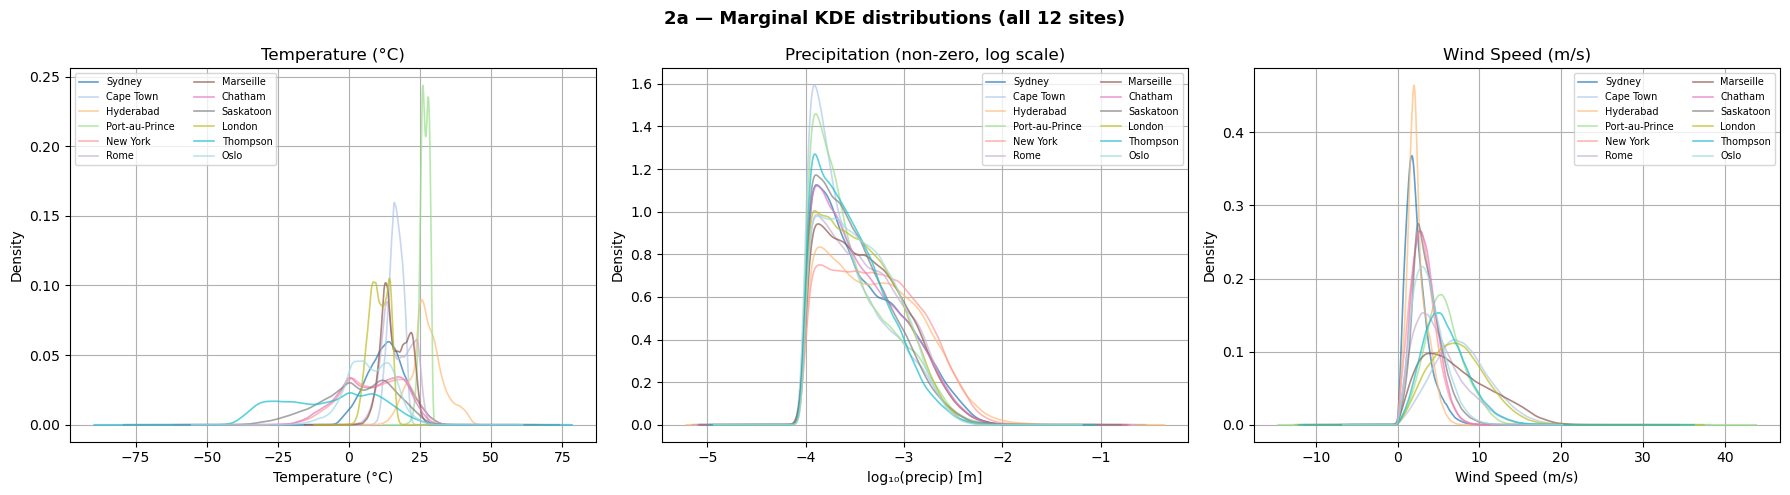


Precipitation zero-fraction per site:
  Marseille         : 55.6% of hours are zero
  Hyderabad         : 54.8% of hours are zero
  Rome              : 46.9% of hours are zero
  Saskatoon         : 46.3% of hours are zero
  New York          : 43.9% of hours are zero
  Sydney            : 40.4% of hours are zero
  Chatham           : 33.7% of hours are zero
  Oslo              : 33.0% of hours are zero
  Thompson          : 31.3% of hours are zero
  Cape Town         : 27.1% of hours are zero
  London            : 21.4% of hours are zero
  Port-au-Prince    : 20.7% of hours are zero


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

targets = [
    ('temperature_C', 'Temperature (°C)',                    axes[0], False),
    ('precipitation', 'Precipitation (non-zero, log scale)', axes[1], True),
    ('wind_speed',    'Wind Speed (m/s)',                     axes[2], False),
]

zero_fracs = {}
for col, xlabel, ax, log_scale in targets:
    for site_key, df in site_dfs.items():
        if col not in df.columns:
            continue
        name  = SITE_INFO[site_key]['name']
        color = SITE_COLORS[site_key]
        series = df[col].dropna()
        if col == 'precipitation':
            zf = (series == 0).mean()
            zero_fracs[name] = zf
            series = series[series > 1e-4]
            if log_scale:
                series = np.log10(series)
        try:
            series.plot.kde(ax=ax, color=color, alpha=0.7, linewidth=1.2, label=name)
        except Exception:
            pass
    ax.set_xlabel('log\u2081\u2080(precip) [m]' if (col=='precipitation' and log_scale) else xlabel)
    ax.set_ylabel('Density')
    ax.set_title(xlabel)
    ax.legend(fontsize=7, ncol=2)

plt.suptitle('2a \u2014 Marginal KDE distributions (all 12 sites)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOT_DIR + '2a_kde_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nPrecipitation zero-fraction per site:')
for name, zf in sorted(zero_fracs.items(), key=lambda x: x[1], reverse=True):
    print(f'  {name:18s}: {zf*100:.1f}% of hours are zero')


### 2b — Seasonal Cycle (Monthly Box Plots)

Monthly distributions of temperature and precipitation per site. Sites with a **double
annual peak** in precipitation (e.g. Hyderabad monsoon vs London year-round) require
longer lag windows in Task B.

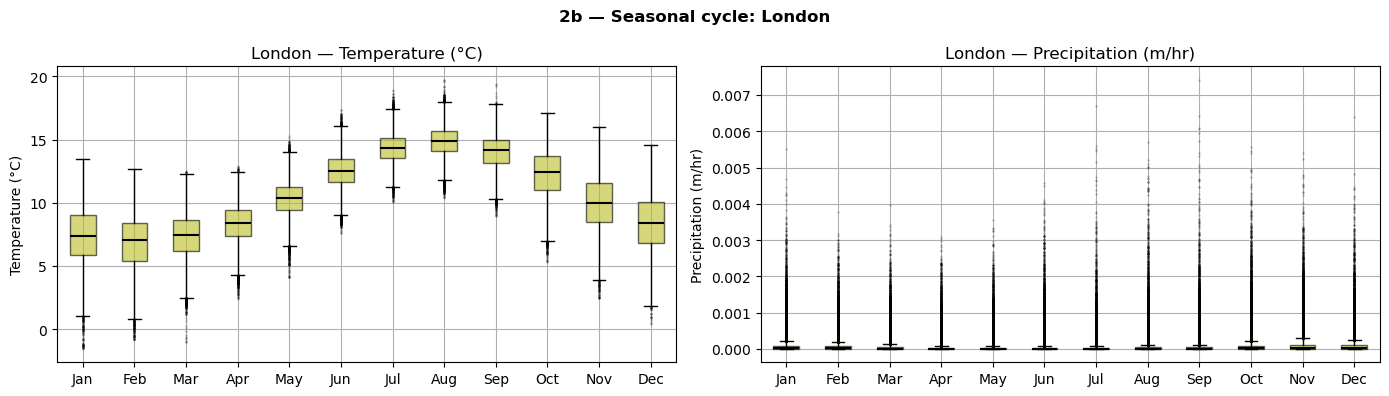

All seasonal box plots saved to ./dataset/eda_plots/


In [8]:
MONTH_LABELS = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

for site_key, df in site_dfs.items():
    name  = SITE_INFO[site_key]['name']
    color = SITE_COLORS[site_key]

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    for ax, col, ylabel in [
        (axes[0], 'temperature_C',  'Temperature (°C)'),
        (axes[1], 'precipitation',  'Precipitation (m/hr)'),
    ]:
        if col not in df.columns:
            continue
        monthly_data = [df.loc[df.index.month == m, col].dropna().values
                        for m in range(1, 13)]
        bp = ax.boxplot(monthly_data, patch_artist=True,
                        medianprops=dict(color='black', linewidth=1.5),
                        flierprops=dict(marker='.', markersize=1, alpha=0.3))
        for patch in bp['boxes']:
            patch.set_facecolor(color)
            patch.set_alpha(0.6)
        ax.set_xticks(range(1, 13))
        ax.set_xticklabels(MONTH_LABELS)
        ax.set_ylabel(ylabel)
        ax.set_title(f'{name} — {ylabel}')

    plt.suptitle(f'2b — Seasonal cycle: {name}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(PLOT_DIR + f'2b_seasonal_{name.replace(" ","_")}.png', dpi=150, bbox_inches='tight')

    # Only display inline for London to keep notebook compact
    if name == 'London':
        plt.show()
    else:
        plt.close()

print('All seasonal box plots saved to', PLOT_DIR)

### 2c — Diurnal Cycle

Mean value by hour-of-day for temperature and shortwave radiation. A strong 24 h cycle
is expected for radiation (zero at night) and a weaker one for temperature.
We quantify the **amplitude** = max(hourly_mean) − min(hourly_mean) per site.

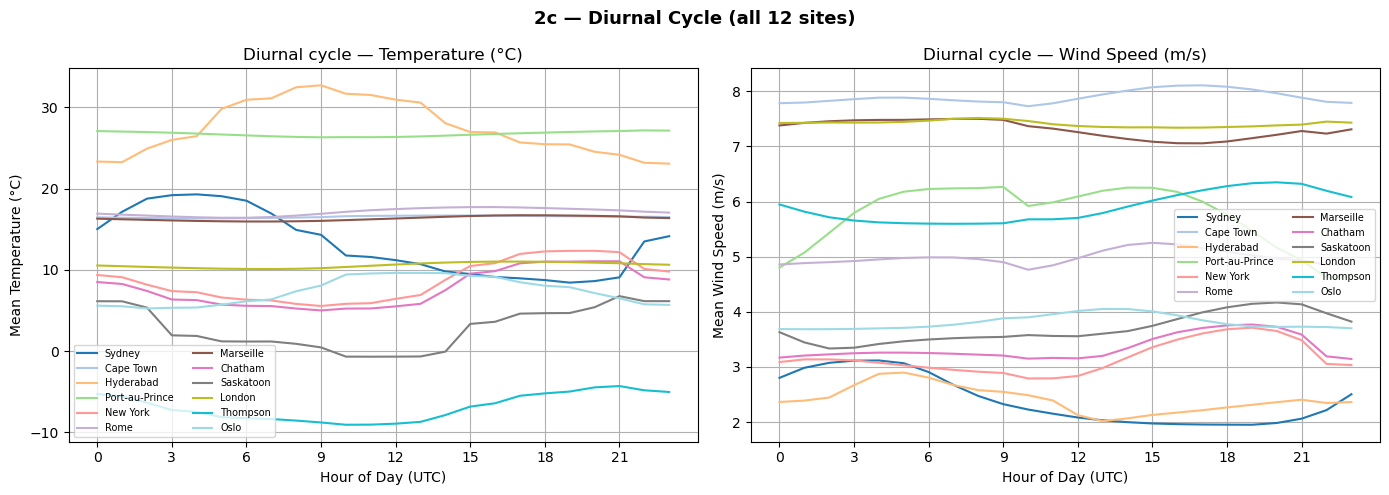


Diurnal amplitude per site:


,Temp amplitude (°C),Wind amplitude (m/s)
Site,,
Sydney,10.86,1.17
Cape Town,0.35,0.38
Hyderabad,9.64,0.88
Port-au-Prince,0.85,1.65
New York,6.79,0.92
Rome,1.31,0.49
Marseille,0.77,0.44
Chatham,6.05,0.62
Saskatoon,7.45,0.83


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

amplitude_rows = []
for site_key, df in site_dfs.items():
    name  = SITE_INFO[site_key]['name']
    color = SITE_COLORS[site_key]
    hourly_temp  = df.groupby(df.index.hour)['temperature_C'].mean()
    hourly_wind  = df.groupby(df.index.hour)['wind_speed'].mean()
    axes[0].plot(hourly_temp.index, hourly_temp.values, color=color, label=name, linewidth=1.5)
    axes[1].plot(hourly_wind.index, hourly_wind.values, color=color, label=name, linewidth=1.5)
    amplitude_rows.append({
        'Site':                  name,
        'Temp amplitude (°C)':   round(hourly_temp.max() - hourly_temp.min(), 2),
        'Wind amplitude (m/s)':  round(hourly_wind.max() - hourly_wind.min(), 2),
    })

for ax, title, ylabel in [
    (axes[0], 'Temperature (°C)', 'Mean Temperature (°C)'),
    (axes[1], 'Wind Speed (m/s)', 'Mean Wind Speed (m/s)'),
]:
    ax.set_xlabel('Hour of Day (UTC)')
    ax.set_ylabel(ylabel)
    ax.set_title(f'Diurnal cycle \u2014 {title}')
    ax.set_xticks(range(0, 24, 3))
    ax.legend(fontsize=7, ncol=2)

plt.suptitle('2c \u2014 Diurnal Cycle (all 12 sites)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOT_DIR + '2c_diurnal_cycle.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nDiurnal amplitude per site:')
display(pd.DataFrame(amplitude_rows).set_index('Site'))


---
## Section 3 — Temporal Structure (Task B — Forecasting)

### 3a — STL Decomposition

STL decomposes `temperature_C` into **trend**, **seasonal** (annual) and **residual**
components. We use **daily resampled data** with `period=365` for tractable runtime
(full hourly with `period=8760` would take ~30 min per site on Colab; users can enable
the hourly version by setting `USE_HOURLY_STL = True`).

**Interpretation:** If the trend component explains a large fraction of variance, models
must capture the long-term warming signal explicitly rather than differencing it away.

STL decomposition:  75%|███████▌  | 9/12 [01:13<00:24,  8.09s/it]

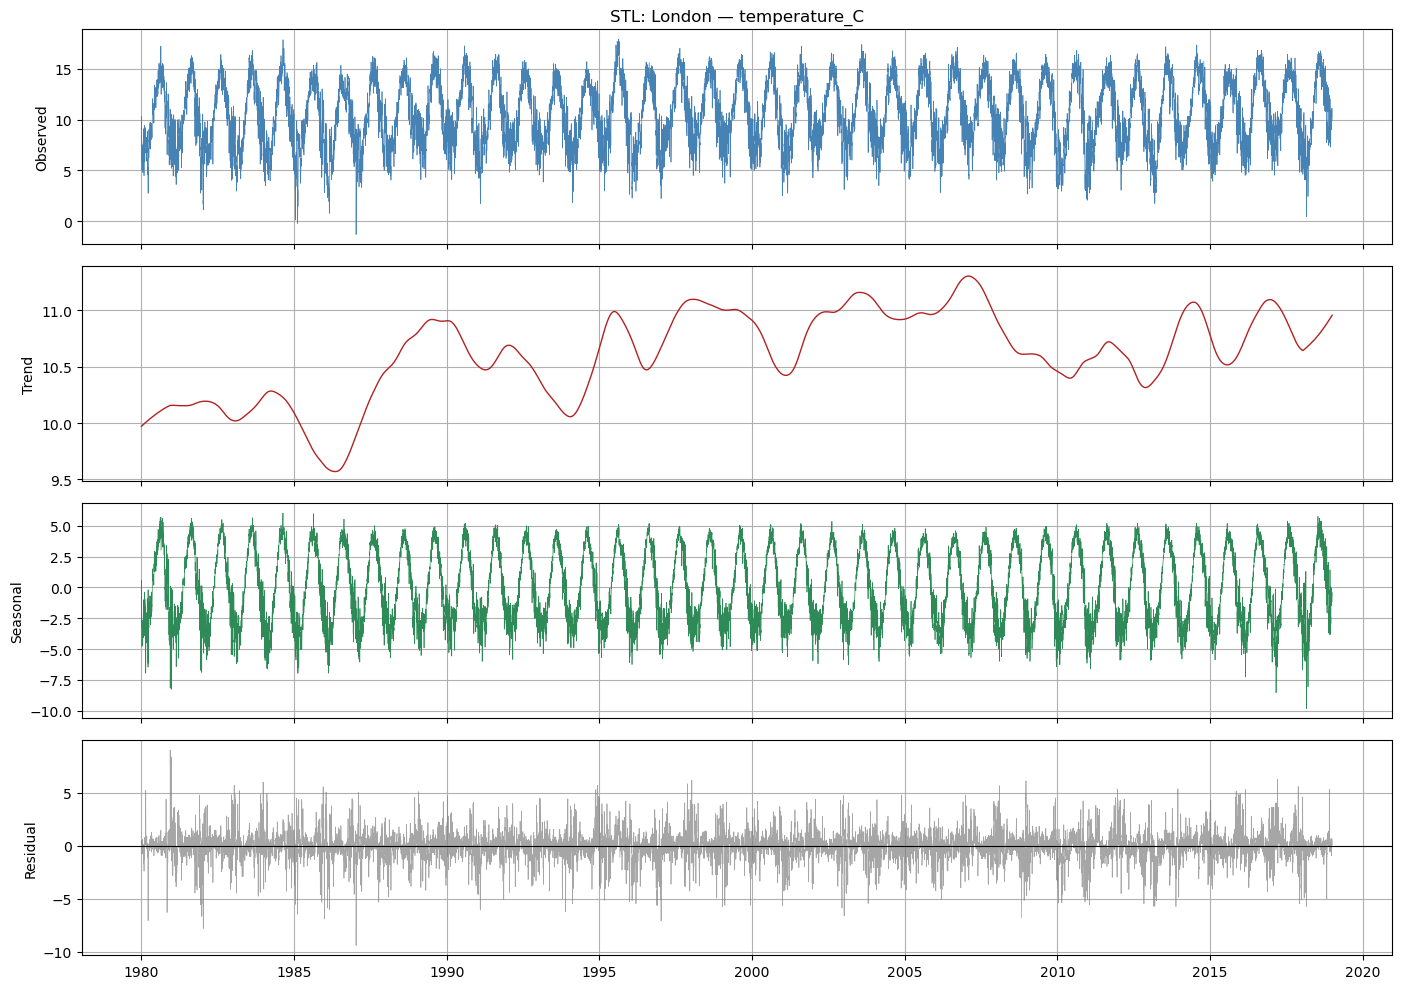

STL decomposition: 100%|██████████| 12/12 [01:37<00:00,  8.13s/it]


STL variance decomposition:


,Trend %,Seasonal %,Residual %
Site,,,
Sydney,0.5,82.0,19.0
Cape Town,1.4,68.0,31.2
Hyderabad,0.7,91.2,12.2
Port-au-Prince,2.6,73.2,20.1
New York,0.3,86.4,14.2
Rome,0.7,86.3,9.0
Marseille,0.9,84.6,9.8
Chatham,0.4,85.2,17.0
Saskatoon,0.2,78.2,19.9


In [10]:
USE_HOURLY_STL = False  # Set True for full-resolution (much slower)

stl_variance_rows = []

for site_key, df in tqdm(site_dfs.items(), desc='STL decomposition'):
    name = SITE_INFO[site_key]['name']

    if USE_HOURLY_STL:
        series = df['temperature_C'].dropna()
        period = 8760
    else:
        series = df['temperature_C'].resample('D').mean().dropna()
        period = 365

    try:
        stl = STL(series, period=period, robust=True)
        result = stl.fit()

        total_var   = np.var(series.values)
        trend_var   = np.var(result.trend)
        seasonal_var = np.var(result.seasonal)
        resid_var   = np.var(result.resid)

        stl_variance_rows.append({
            'Site':          name,
            'Trend %':       round(100 * trend_var   / total_var, 1),
            'Seasonal %':    round(100 * seasonal_var / total_var, 1),
            'Residual %':    round(100 * resid_var   / total_var, 1),
        })

        # Save all to disk
        fig2, axs = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
        axs[0].plot(series.index, series.values,       color='steelblue', linewidth=0.5)
        axs[0].set_ylabel('Observed'); axs[0].set_title(f'STL: {name} — temperature_C')
        axs[1].plot(series.index, result.trend,        color='firebrick',  linewidth=1)
        axs[1].set_ylabel('Trend')
        axs[2].plot(series.index, result.seasonal,     color='seagreen',   linewidth=0.5)
        axs[2].set_ylabel('Seasonal')
        axs[3].plot(series.index, result.resid,        color='grey',       linewidth=0.5, alpha=0.7)
        axs[3].axhline(0, color='black', linewidth=0.8)
        axs[3].set_ylabel('Residual')
        plt.tight_layout()
        plt.savefig(PLOT_DIR + f'3a_stl_{name.replace(" ","_")}.png', dpi=150, bbox_inches='tight')

        if name == 'London':
            plt.show()
        else:
            plt.close()

    except Exception as e:
        print(f'  STL failed for {name}: {e}')
        plt.close()

print('\nSTL variance decomposition:')
display(pd.DataFrame(stl_variance_rows).set_index('Site'))

### 3b — Stationarity Tests: ADF & KPSS

Tests are run on **daily-mean** resampled data (one value per day) to keep runtime
manageable. Full-hourly results may show stronger non-stationarity due to diurnal cycles.

**Verdicts:**
- ADF rejects H₀ (unit root) AND KPSS does not reject H₀ (stationary around mean) → **Stationary**
- ADF rejects H₀ AND KPSS rejects H₀ → **Trend-stationary** (stationary after detrending)
- ADF does NOT reject H₀ → **Unit-root** (needs differencing)

In [11]:
stat_rows = []

for site_key, df in tqdm(site_dfs.items(), desc='Stationarity tests'):
    name = SITE_INFO[site_key]['name']
    cols_avail = [c for c in NUMERIC_COLS if c in df.columns]
    daily = df[cols_avail].resample('D').mean()

    for col in cols_avail:
        if col not in daily.columns:
            continue
        series = daily[col].dropna()
        if len(series) < 100:
            continue
        try:
            adf_stat, adf_p, *_ = adfuller(series, autolag='AIC')
        except Exception:
            adf_p = np.nan
        try:
            kpss_stat, kpss_p, *_ = kpss(series, regression='ct', nlags='auto')
        except Exception:
            kpss_p = np.nan

        # Verdict
        adf_reject  = (not np.isnan(adf_p))  and (adf_p  < 0.05)
        kpss_reject = (not np.isnan(kpss_p)) and (kpss_p < 0.05)
        if adf_reject and not kpss_reject:
            verdict = 'Stationary'
        elif adf_reject and kpss_reject:
            verdict = 'Trend-stationary'
        else:
            verdict = 'Unit-root'

        stat_rows.append({
            'Site':       name,
            'Variable':   col,
            'ADF p-val':  round(adf_p, 4)  if not np.isnan(adf_p)  else np.nan,
            'KPSS p-val': round(kpss_p, 4) if not np.isnan(kpss_p) else np.nan,
            'Verdict':    verdict,
        })

stat_df = pd.DataFrame(stat_rows)
print('Stationarity results (first 30 rows):')
display(stat_df.head(30))

# Pivot to site x variable for verdicts on temperature_C
print('\nVerdict for temperature_C across sites:')
display(stat_df[stat_df['Variable']=='temperature_C'][['Site','ADF p-val','KPSS p-val','Verdict']])

Stationarity tests:   0%|          | 0/12 [00:00<?, ?it/s]/var/folders/fk/ll3l7v357w716c7kcmcq7m9m0000gn/T/ipykernel_60734/3083341920.py:19: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(series, regression='ct', nlags='auto')
/var/folders/fk/ll3l7v357w716c7kcmcq7m9m0000gn/T/ipykernel_60734/3083341920.py:19: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(series, regression='ct', nlags='auto')
/var/folders/fk/ll3l7v357w716c7kcmcq7m9m0000gn/T/ipykernel_60734/3083341920.py:19: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(series, regression='c

Stationarity results (first 30 rows):


,Site,Variable,ADF p-val,KPSS p-val,Verdict
0,Sydney,temperature_K,0.0,0.1,Stationary
1,Sydney,precipitation,0.0,0.1,Stationary
2,Sydney,u_wind,0.0,0.1,Stationary
3,Sydney,v_wind,0.0,0.1,Stationary
4,Sydney,temperature_C,0.0,0.1,Stationary
5,Sydney,wind_speed,0.0,0.1,Stationary
6,Sydney,wind_dir_deg,0.0,0.1,Stationary
7,Cape Town,temperature_K,0.0,0.1,Stationary
8,Cape Town,precipitation,0.0,0.1,Stationary
9,Cape Town,u_wind,0.0,0.1,Stationary



Verdict for temperature_C across sites:


,Site,ADF p-val,KPSS p-val,Verdict
4,Sydney,0.0,0.1,Stationary
11,Cape Town,0.0,0.1,Stationary
18,Hyderabad,0.0,0.1,Stationary
25,Port-au-Prince,0.0,0.1,Stationary
32,New York,0.0,0.1,Stationary
39,Rome,0.0,0.1,Stationary
46,Marseille,0.0,0.1,Stationary
53,Chatham,0.0,0.1,Stationary
60,Saskatoon,0.0,0.1,Stationary
67,London,0.0,0.1,Stationary


### 3c — ACF / PACF Analysis

ACF and PACF for **daily** temperature and precipitation, out to lag 365 days.
Two contrasting sites: **London** (temperate, year-round precip) and **Hyderabad** (monsoon).

Key features to identify:
- Lag at which autocorrelation first drops below 95% confidence band
- Annual seasonality spike near lag 365
- Precipitation: meaningful autocorrelation beyond 1–2 days?

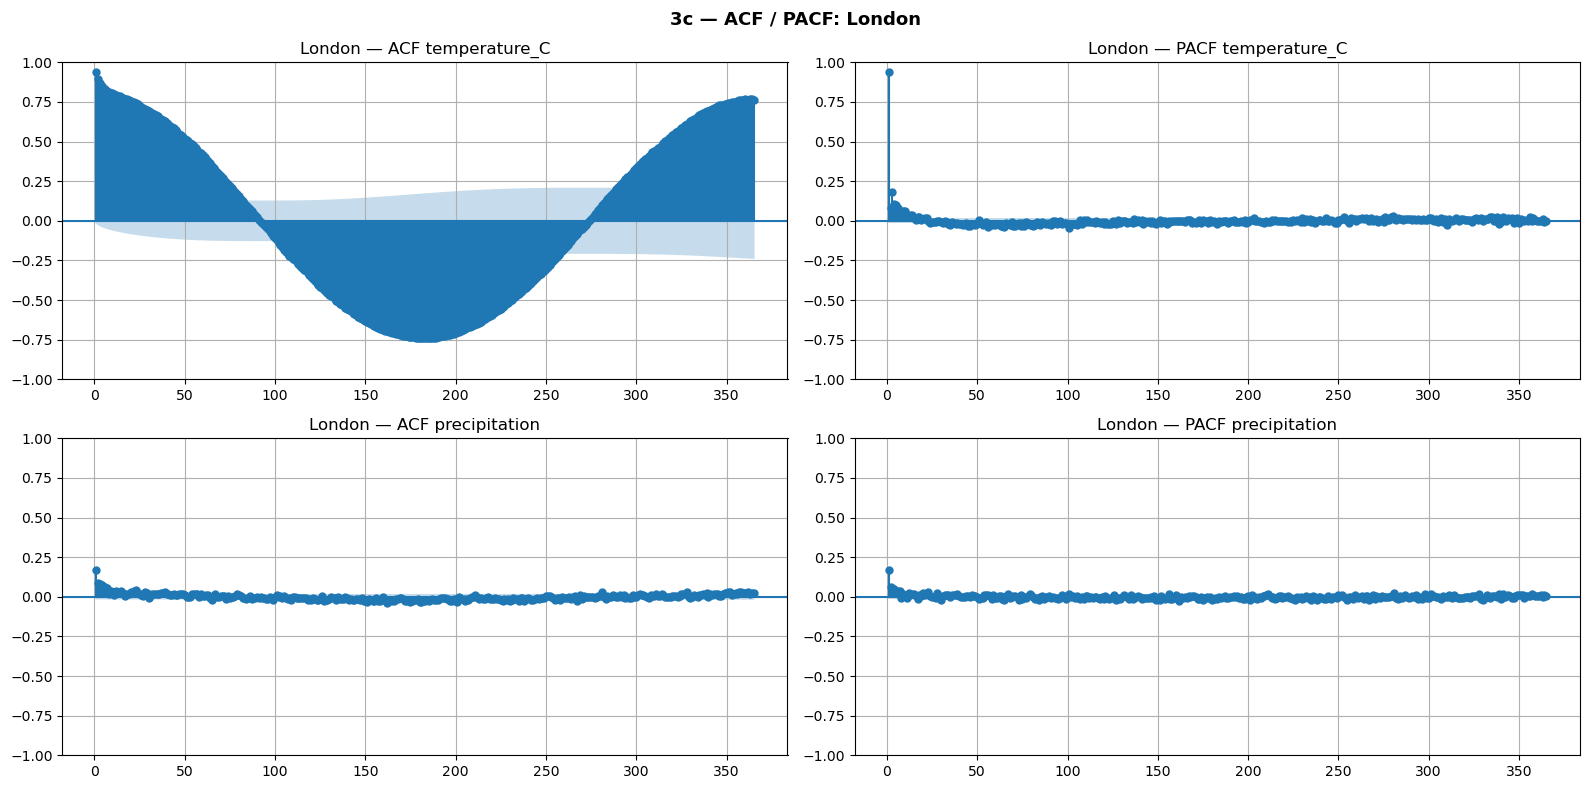

London: temperature_C ACF drops below 95% CI at lag never within 30 lags days   (CI = ±0.0164)


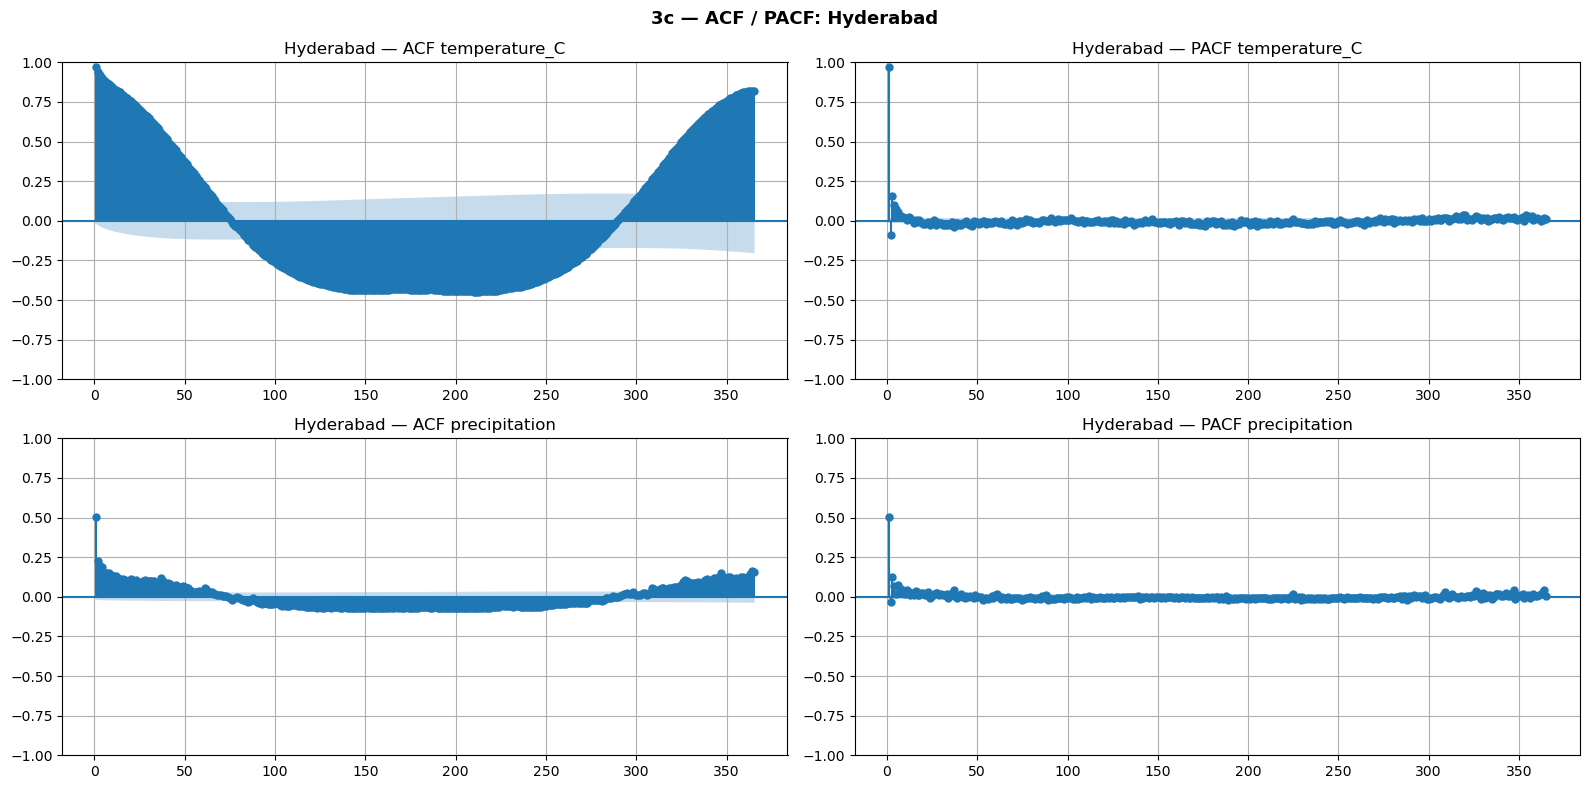

Hyderabad: temperature_C ACF drops below 95% CI at lag never within 30 lags days   (CI = ±0.0164)


In [12]:
ACF_SITES = ['51.5N_359.9E', '17.36N_78.5E']  # London, Hyderabad
ACF_LAGS  = 365

for site_key in ACF_SITES:
    if site_key not in site_dfs:
        continue
    df   = site_dfs[site_key]
    name = SITE_INFO[site_key]['name']
    daily = df[['temperature_C','precipitation']].resample('D').mean()

    fig, axes = plt.subplots(2, 2, figsize=(16, 8))

    for col_idx, col in enumerate(['temperature_C', 'precipitation']):
        series = daily[col].dropna()
        ax_acf  = axes[col_idx, 0]
        ax_pacf = axes[col_idx, 1]
        try:
            plot_acf( series, lags=ACF_LAGS, ax=ax_acf,  alpha=0.05,
                      title=f'{name} — ACF {col}',  zero=False)
            plot_pacf(series, lags=min(ACF_LAGS, int(len(series)/2) - 1),
                      ax=ax_pacf, alpha=0.05, method='ywm',
                      title=f'{name} — PACF {col}', zero=False)
        except Exception as e:
            ax_acf.set_title(f'{col}: {e}')

    plt.suptitle(f'3c — ACF / PACF: {name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(PLOT_DIR + f'3c_acf_pacf_{name.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Report first lag below significance (95% CI ≈ 1.96/sqrt(n))
    n = len(daily['temperature_C'].dropna())
    ci = 1.96 / np.sqrt(n)
    temp_series = daily['temperature_C'].dropna()
    acf_vals = [temp_series.autocorr(lag=l) for l in range(1, min(30, len(temp_series)))]
    first_insig = next((i+1 for i, v in enumerate(acf_vals) if abs(v) < ci), 'never within 30 lags')
    print(f'{name}: temperature_C ACF drops below 95% CI at lag {first_insig} days   (CI = ±{ci:.4f})')

### 3d — Cross-Correlation Heatmaps (per site)

Pearson correlation matrices for all numeric variables. Cells with |r| > 0.5 are annotated `*`.
Key pairs to watch: temperature ↔ radiation, precipitation ↔ RH, dewpoint ↔ temperature,
wind components ↔ pressure.

London is shown inline; all 12 saved to disk.

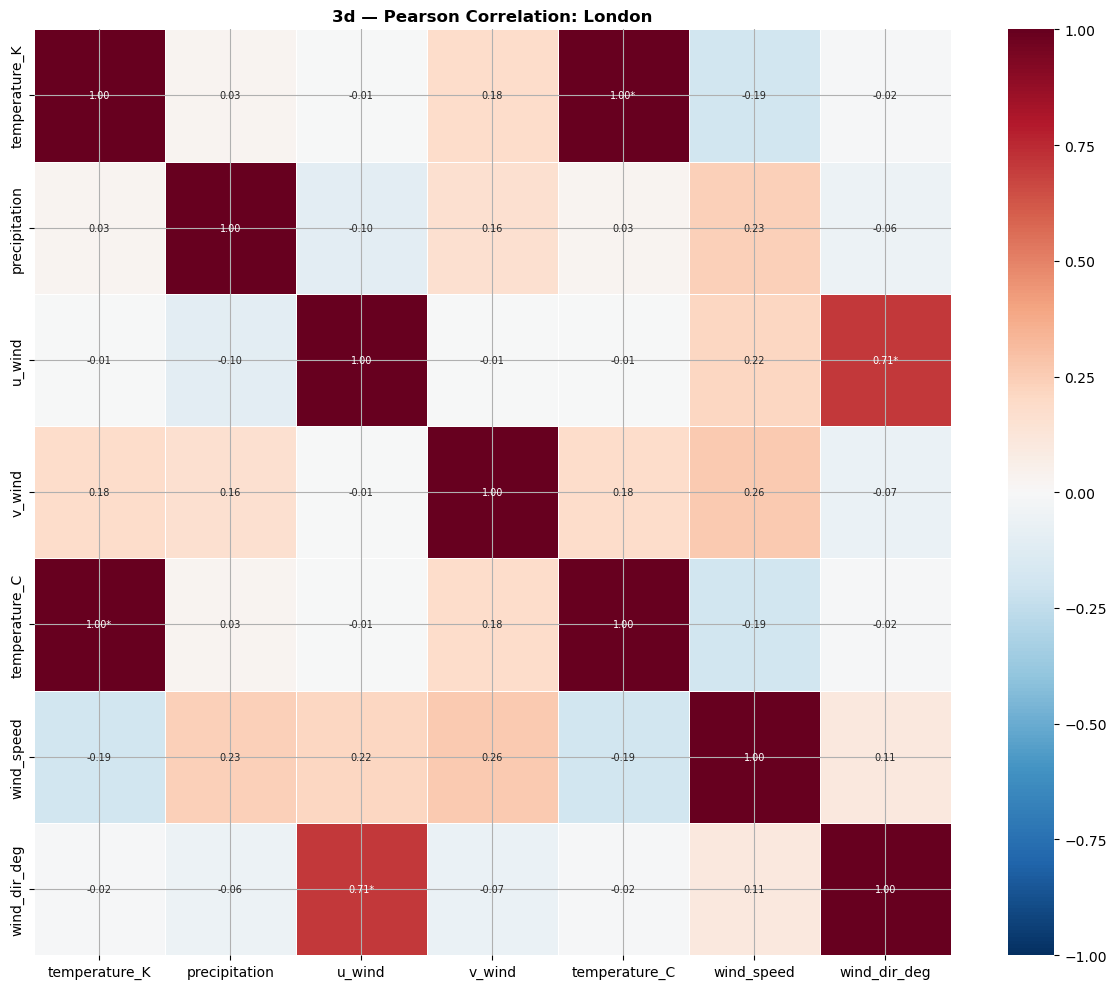

All correlation heatmaps saved to ./dataset/eda_plots/


In [13]:
def plot_corr_heatmap(df, name, save_path, show=False):
    cols = [c for c in NUMERIC_COLS if c in df.columns]
    corr = df[cols].corr(method='pearson')

    # Build annotation matrix: value + '*' if |r| > 0.5
    annot = corr.copy().astype(str)
    for r in corr.index:
        for c in corr.columns:
            v = corr.loc[r, c]
            star = '*' if abs(v) > 0.5 and r != c else ''
            annot.loc[r, c] = f'{v:.2f}{star}'

    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(corr, annot=annot, fmt='', cmap='RdBu_r', center=0,
                vmin=-1, vmax=1, linewidths=0.5, ax=ax,
                annot_kws={'size': 7})
    ax.set_title(f'3d — Pearson Correlation: {name}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    if show:
        plt.show()
    else:
        plt.close()
    return corr

for site_key, df in site_dfs.items():
    name  = SITE_INFO[site_key]['name']
    show  = (name == 'London')
    corr  = plot_corr_heatmap(df, name,
                               PLOT_DIR + f'3d_corr_{name.replace(" ","_")}.png',
                               show=show)

print('All correlation heatmaps saved to', PLOT_DIR)

---
## Section 4 — Spatial Structure (Task C — Location Extrapolation)

### 4a — Inter-Site Correlation Matrix

For each key variable, pairwise Pearson r between all 12 sites using **annual means**
(38 data points per pair). Sites ordered south → north by latitude.

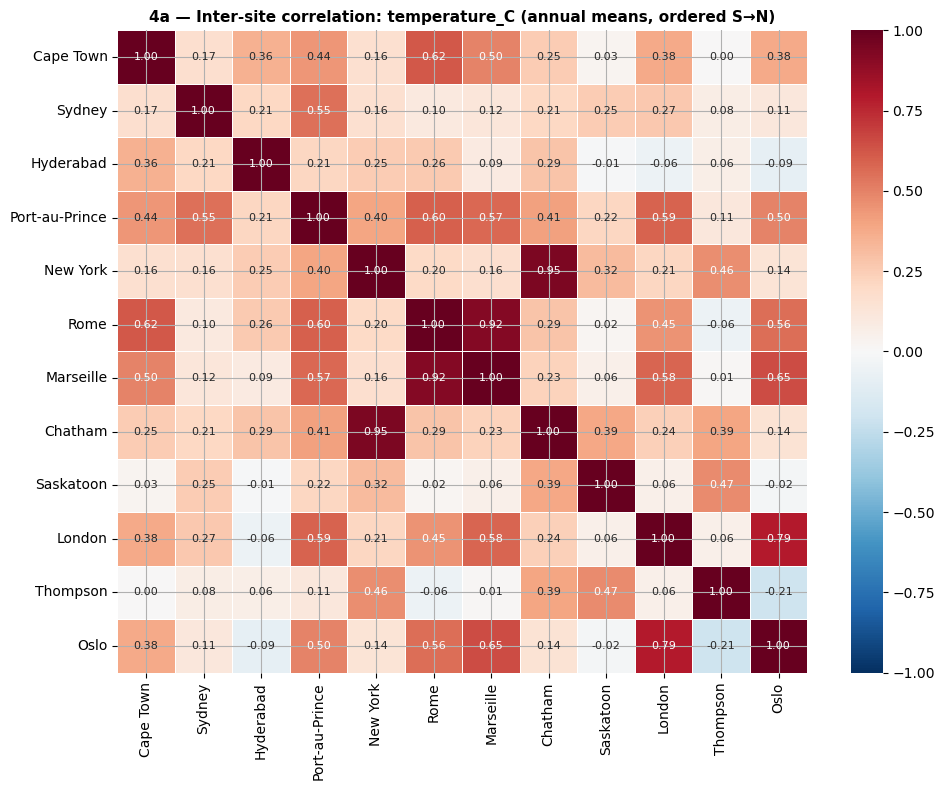

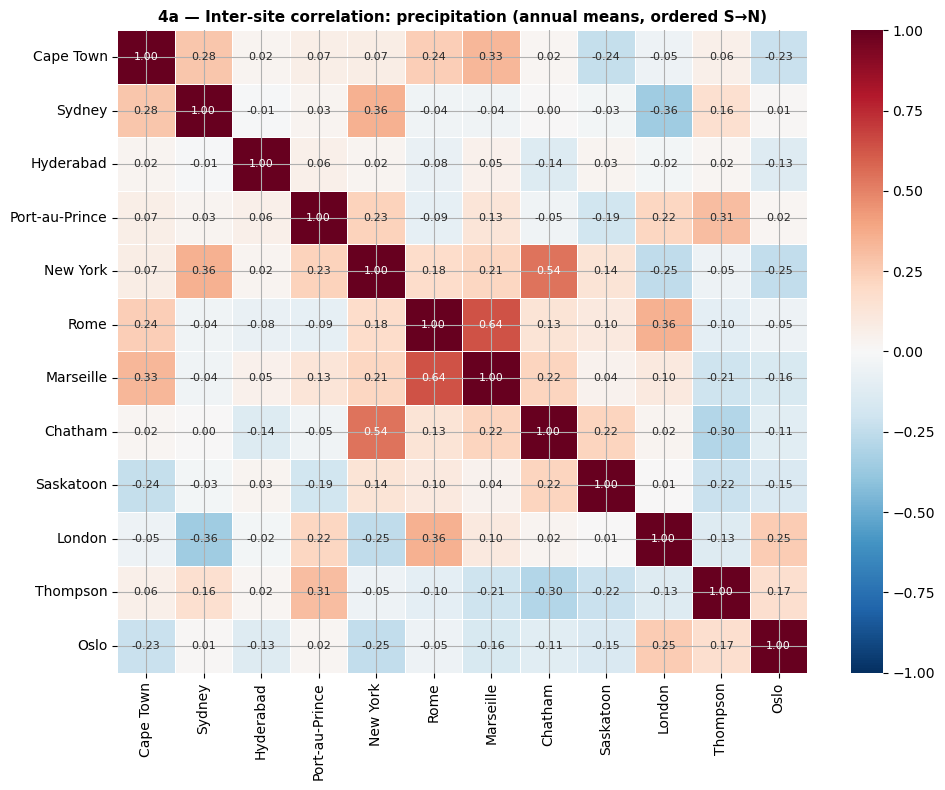

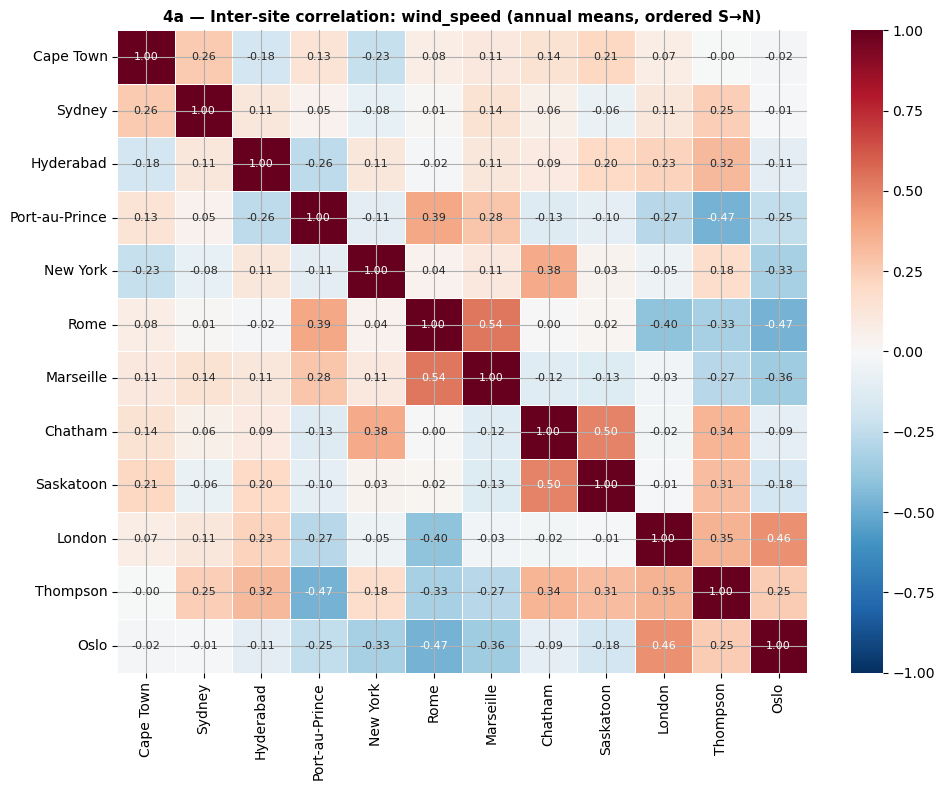

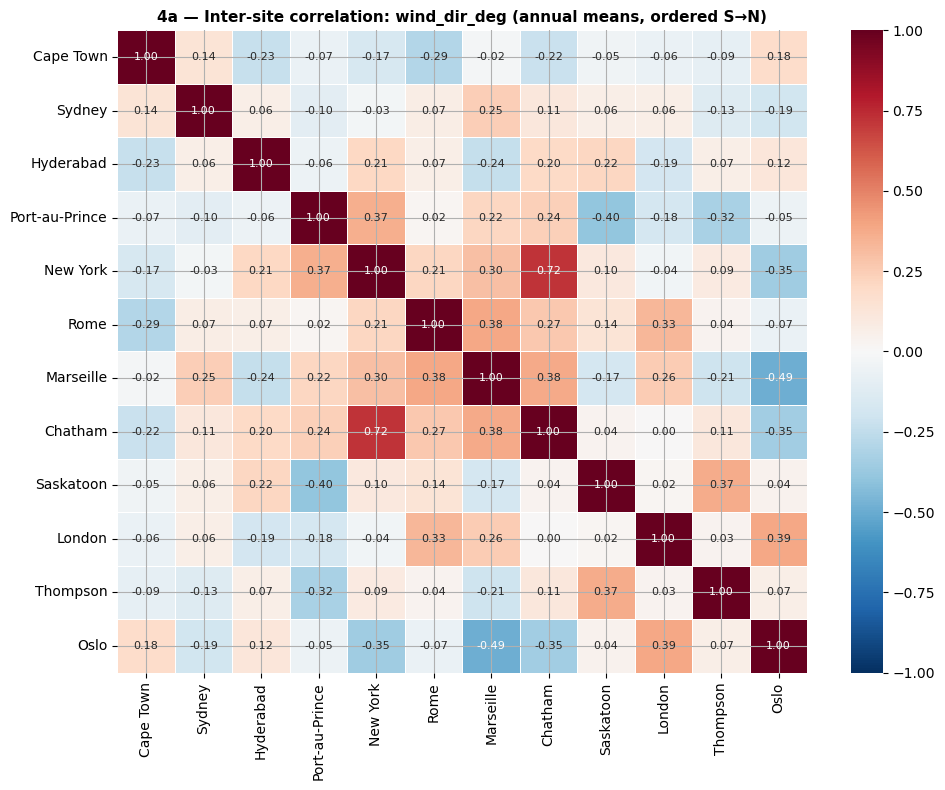

In [14]:
inter_vars = ['temperature_C', 'precipitation', 'wind_speed', 'wind_dir_deg']

for var in inter_vars:
    # Build DataFrame: index=year, columns=site_name
    ann_means = {}
    for site_key in SITE_KEYS_BY_LAT:
        if site_key not in site_dfs:
            continue
        df = site_dfs[site_key]
        if var not in df.columns:
            continue
        ann = df[var].groupby(df.index.year).mean()
        ann_means[SITE_INFO[site_key]['name']] = ann

    ann_df  = pd.DataFrame(ann_means).dropna()
    corr_mat = ann_df.corr(method='pearson')

    fig, ax = plt.subplots(figsize=(10, 8))
    mask = np.zeros_like(corr_mat, dtype=bool)
    np.fill_diagonal(mask, True)  # keep diagonal but don't annotate diag differently
    sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                vmin=-1, vmax=1, linewidths=0.5, ax=ax, annot_kws={'size': 8})
    ax.set_title(f'4a — Inter-site correlation: {var} (annual means, ordered S→N)',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig(PLOT_DIR + f'4a_intersite_corr_{var}.png', dpi=150, bbox_inches='tight')
    plt.show()

### 4b — Climate Regime Clustering

Features: annual mean temperature (°C), annual total precipitation (mm/year), annual mean
shortwave radiation (W m⁻²). Ward linkage hierarchical clustering + K-means with k=3.

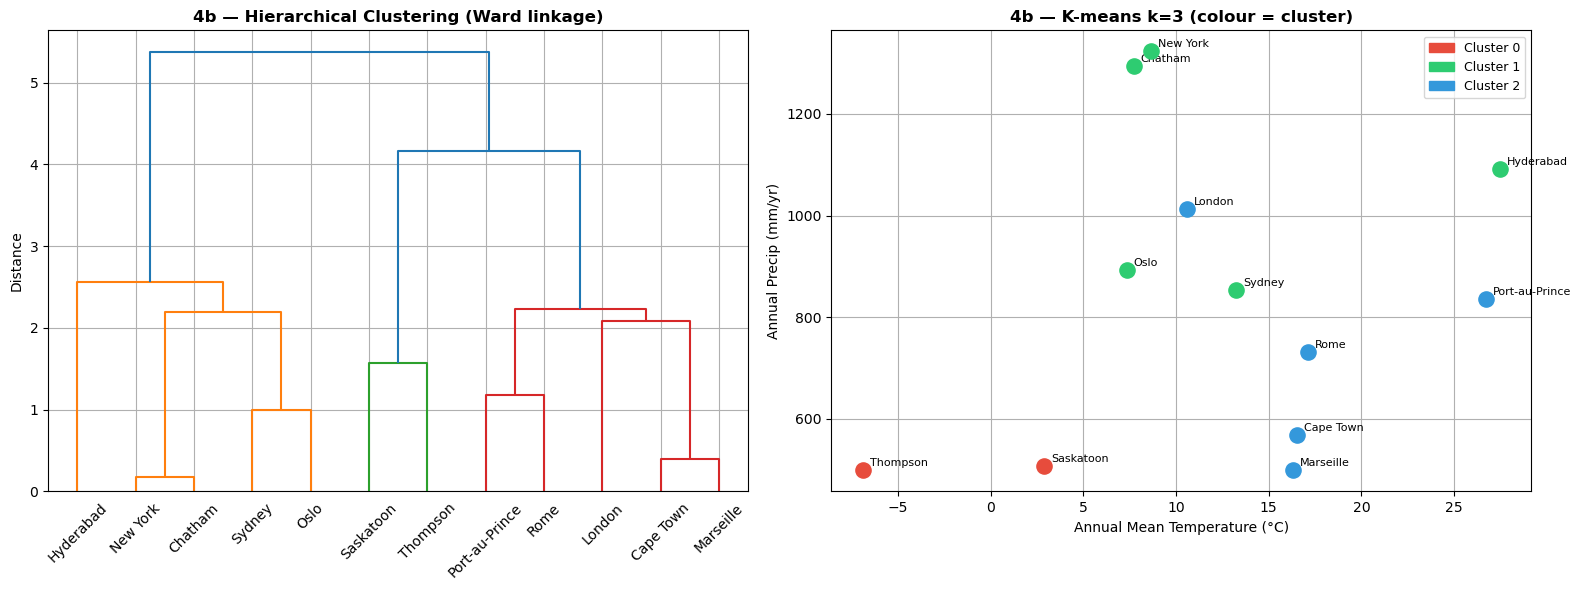


K-means cluster assignments:


,temp_C,precip_mm_yr,wind_ms,KMeans_cluster
Site,,,,
Cape Town,16.512673,567.704368,7.897257,2
Sydney,13.250657,853.301950,2.400477,1
Hyderabad,27.451866,1091.258815,2.413507,1
Port-au-Prince,26.713010,835.613546,5.740731,2
New York,8.654283,1323.465239,3.166399,1
Rome,17.104725,731.358722,4.982705,2
Marseille,16.313009,498.178519,7.309401,2
Chatham,7.716593,1293.585843,3.347411,1
Saskatoon,2.865863,506.915065,3.693137,0


In [15]:
cluster_rows = []
for site_key in SITE_KEYS_BY_LAT:
    if site_key not in site_dfs:
        continue
    df   = site_dfs[site_key]
    name = SITE_INFO[site_key]['name']
    t_mean  = df['temperature_C'].mean()       if 'temperature_C'      in df.columns else np.nan
    p_total = df['precipitation'].sum() * 1000 if 'precipitation'       in df.columns else np.nan  # m→mm over all hours
    n_years = (df.index.max() - df.index.min()).days / 365.25
    p_ann   = p_total / n_years
    r_mean  = df['wind_speed'].mean()           if 'wind_speed'           in df.columns else np.nan
    cluster_rows.append({'Site': name, 'temp_C': t_mean, 'precip_mm_yr': p_ann, 'wind_ms': r_mean})

clust_df = pd.DataFrame(cluster_rows).set_index('Site').dropna()
scaler   = StandardScaler()
X        = scaler.fit_transform(clust_df.values)
site_names_list = list(clust_df.index)

# ── Ward linkage dendrogram ──────────────────────────────────────────────────
Z = linkage(X, method='ward')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

dendrogram(Z, labels=site_names_list, ax=axes[0], leaf_rotation=45, leaf_font_size=10,
           color_threshold=0.7*max(Z[:, 2]))
axes[0].set_title('4b — Hierarchical Clustering (Ward linkage)', fontweight='bold')
axes[0].set_ylabel('Distance')

# ── K-means k=3 ──────────────────────────────────────────────────────────────
km = KMeans(n_clusters=3, random_state=42, n_init=20)
labels = km.fit_predict(X)
cluster_labels = {site: lbl for site, lbl in zip(site_names_list, labels)}

regime_colors = ['#e74c3c', '#2ecc71', '#3498db']  # tropical, temperate, sub-arctic
for i, (site_name, row) in enumerate(clust_df.iterrows()):
    c = regime_colors[labels[i]]
    axes[1].scatter(row['temp_C'], row['precip_mm_yr'], color=c, s=120, zorder=5)
    axes[1].annotate(site_name, (row['temp_C'], row['precip_mm_yr']),
                     textcoords='offset points', xytext=(5, 3), fontsize=8)
axes[1].set_xlabel('Annual Mean Temperature (°C)')
axes[1].set_ylabel('Annual Precip (mm/yr)')
axes[1].set_title('4b — K-means k=3 (colour = cluster)', fontweight='bold')
from matplotlib.patches import Patch
axes[1].legend(handles=[
    Patch(color=regime_colors[0], label='Cluster 0'),
    Patch(color=regime_colors[1], label='Cluster 1'),
    Patch(color=regime_colors[2], label='Cluster 2'),
], fontsize=9)

plt.tight_layout()
plt.savefig(PLOT_DIR + '4b_clustering.png', dpi=150, bbox_inches='tight')
plt.show()

clust_df['KMeans_cluster'] = labels
print('\nK-means cluster assignments:')
display(clust_df)

### 4c — PCA of Spatial Patterns

12 × p matrix of annual-mean feature vectors. PCA reveals the dominant axes of
inter-site variation.

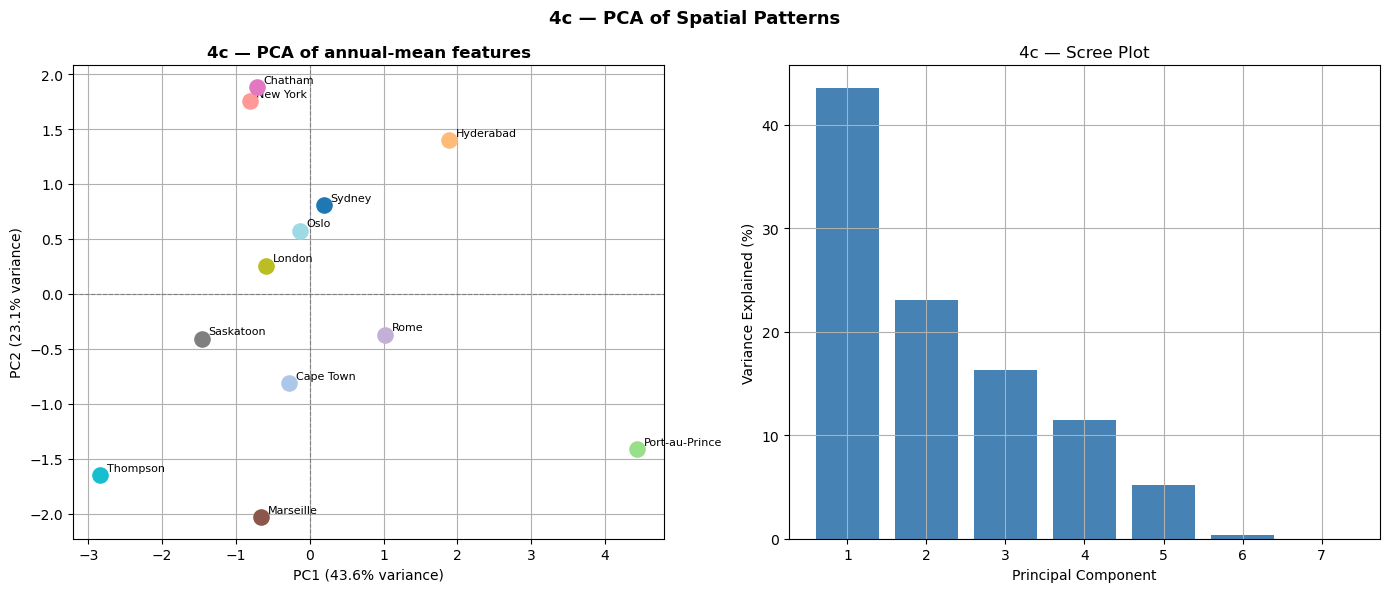

PC1 explains 43.6% of inter-site variance
PC2 explains 23.1% of inter-site variance
PC1+PC2 combined: 66.7%


In [16]:
# Build feature matrix: annual means of all numeric columns
pca_rows = []
pca_sites = []
for site_key in SITE_KEYS_BY_LAT:
    if site_key not in site_dfs:
        continue
    df   = site_dfs[site_key]
    name = SITE_INFO[site_key]['name']
    cols_avail = [c for c in NUMERIC_COLS if c in df.columns]
    ann_means_vec = df[cols_avail].mean().values
    pca_rows.append(ann_means_vec)
    pca_sites.append(name)

pca_X_raw = np.array(pca_rows)          # shape: (12, p)
pca_X_raw = np.nan_to_num(pca_X_raw, nan=0.0)

scaler_pca = StandardScaler()
pca_X      = scaler_pca.fit_transform(pca_X_raw)

pca = PCA(n_components=min(pca_X.shape))
pca_scores = pca.fit_transform(pca_X)
explained  = pca.explained_variance_ratio_ * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter PC1 vs PC2
ax = axes[0]
for i, sname in enumerate(pca_sites):
    site_key = [k for k in SITE_INFO if SITE_INFO[k]['name'] == sname]
    color = SITE_COLORS[site_key[0]] if site_key else 'grey'
    cluster_lbl = cluster_labels.get(sname, 0)
    ax.scatter(pca_scores[i, 0], pca_scores[i, 1], color=color, s=120, zorder=5)
    ax.annotate(sname, (pca_scores[i, 0], pca_scores[i, 1]),
                textcoords='offset points', xytext=(5, 3), fontsize=8)
ax.set_xlabel(f'PC1 ({explained[0]:.1f}% variance)')
ax.set_ylabel(f'PC2 ({explained[1]:.1f}% variance)')
ax.set_title('4c — PCA of annual-mean features', fontweight='bold')
ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.8, linestyle='--')

# Scree plot
ax2 = axes[1]
ax2.bar(range(1, len(explained)+1), explained, color='steelblue')
ax2.set_xlabel('Principal Component')
ax2.set_ylabel('Variance Explained (%)')
ax2.set_title('4c — Scree Plot')
ax2.set_xticks(range(1, len(explained)+1))

plt.suptitle('4c — PCA of Spatial Patterns', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOT_DIR + '4c_pca_spatial.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'PC1 explains {explained[0]:.1f}% of inter-site variance')
print(f'PC2 explains {explained[1]:.1f}% of inter-site variance')
print(f'PC1+PC2 combined: {explained[0]+explained[1]:.1f}%')

---
## Section 5 — Outlier & Anomaly Characterisation

### 5a — 38-Year Temperature Anomaly Heatmap

Monthly mean temperature anomaly relative to the 1980–2010 climatological baseline.
Blue = cooler than normal, red = warmer. Mann-Kendall trend test on annual means
to identify sites with statistically significant warming.

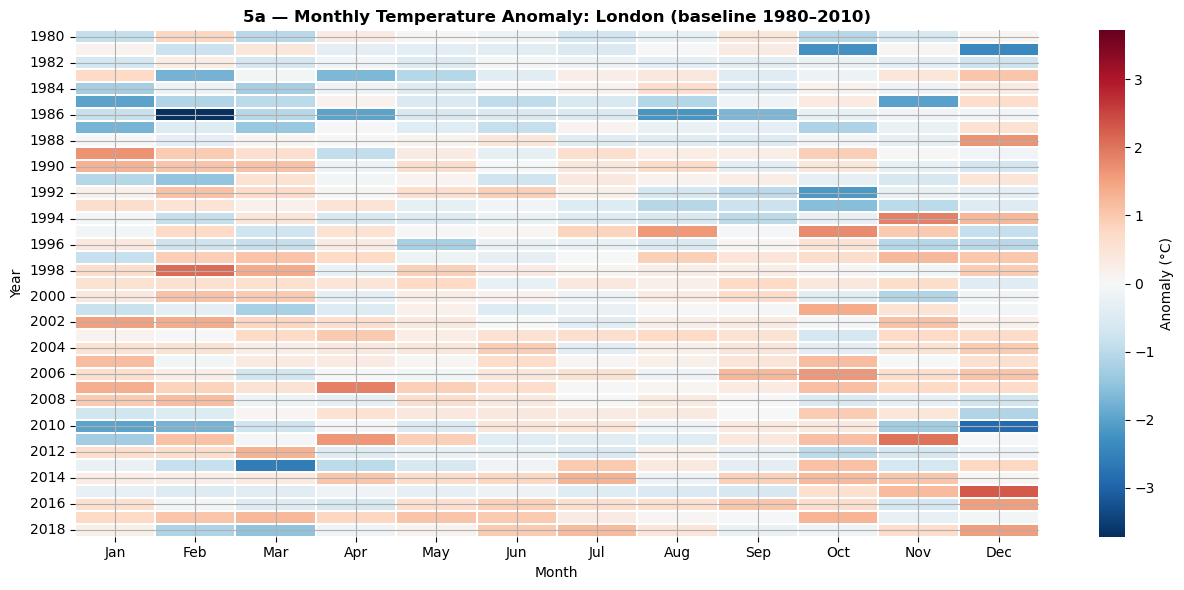


Mann-Kendall trend test on annual mean temperature:


,MK tau,MK p-val,Trend
Site,,,
Cape Town,0.5277,0.0000,increasing
Rome,0.5277,0.0000,increasing
Port-au-Prince,0.4791,0.0000,increasing
Marseille,0.4197,0.0002,increasing
Oslo,0.3603,0.0013,increasing
London,0.3522,0.0017,increasing
Chatham,0.3333,0.0029,increasing
New York,0.2955,0.0084,increasing
Hyderabad,0.2848,0.0111,increasing


In [17]:
mk_rows = []

for site_key, df in site_dfs.items():
    name = SITE_INFO[site_key]['name']
    if 'temperature_C' not in df.columns:
        continue

    # Monthly means
    df_temp = df['temperature_C'].copy()
    monthly_mean = df_temp.groupby([df_temp.index.year, df_temp.index.month]).mean()
    monthly_mean.index.names = ['year', 'month']
    monthly_mean = monthly_mean.reset_index()

    # Climatological mean: 1980-2010
    clim = monthly_mean[monthly_mean['year'].between(1980, 2010)].groupby('month')['temperature_C'].mean()
    monthly_mean['climatology'] = monthly_mean['month'].map(clim)
    monthly_mean['anomaly']     = monthly_mean['temperature_C'] - monthly_mean['climatology']

    # Pivot: rows=year, cols=month
    pivot = monthly_mean.pivot(index='year', columns='month', values='anomaly')
    pivot.columns = [MONTH_LABELS[m-1] for m in pivot.columns]

    # Mann-Kendall on annual means
    annual_mean = df_temp.groupby(df_temp.index.year).mean().dropna()
    try:
        mk_result = mk.original_test(annual_mean.values)
        mk_rows.append({'Site': name, 'MK tau': round(mk_result.Tau, 4),
                        'MK p-val': round(mk_result.p, 4),
                        'Trend': mk_result.trend})
    except Exception as e:
        mk_rows.append({'Site': name, 'MK tau': np.nan, 'MK p-val': np.nan, 'Trend': 'error'})

    # Plot heatmap
    finite_vals = pivot.values[np.isfinite(pivot.values)]
    vmax = max(abs(finite_vals).max() if len(finite_vals) > 0 else 1, 1)
    fig, ax = plt.subplots(figsize=(13, 6))
    sns.heatmap(pivot, cmap='RdBu_r', center=0, vmin=-vmax, vmax=vmax,
                linewidths=0.3, ax=ax, cbar_kws={'label': 'Anomaly (°C)'})
    ax.set_xlabel('Month')
    ax.set_ylabel('Year')
    ax.set_title(f'5a — Monthly Temperature Anomaly: {name} (baseline 1980–2010)',
                 fontweight='bold')
    plt.tight_layout()
    plt.savefig(PLOT_DIR + f'5a_anomaly_{name.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
    if name == 'London':
        plt.show()
    else:
        plt.close()

mk_df = pd.DataFrame(mk_rows).set_index('Site')
print('\nMann-Kendall trend test on annual mean temperature:')
display(mk_df.sort_values('MK tau', ascending=False))

### 5b — Extreme Events

Values beyond the 99th percentile. Top-10 hourly precipitation events and top-10
hottest/coldest temperature hours per site. We check whether extremes cluster
seasonally (month of occurrence).

In [18]:
extreme_summary = []

for site_key, df in site_dfs.items():
    name = SITE_INFO[site_key]['name']

    # ── Precipitation extremes ───────────────────────────────────────────────
    if 'precipitation' in df.columns:
        p99_precip = df['precipitation'].quantile(0.99)
        top10_precip = (df['precipitation']
                        .nlargest(10)
                        .reset_index()
                        .rename(columns={'datetime': 'datetime', 'precipitation': 'value'}))
        top10_precip['month'] = pd.to_datetime(top10_precip['datetime']).dt.month
        season_precip = top10_precip['month'].value_counts().to_dict()
    else:
        p99_precip = np.nan
        season_precip = {}

    # ── Temperature extremes ─────────────────────────────────────────────────
    if 'temperature_C' in df.columns:
        p99_temp = df['temperature_C'].quantile(0.99)
        p01_temp = df['temperature_C'].quantile(0.01)
        top10_hot  = df['temperature_C'].nlargest(10)
        top10_cold = df['temperature_C'].nsmallest(10)
        hot_months  = top10_hot.index.month.tolist()
        cold_months = top10_cold.index.month.tolist()
        hottest  = round(top10_hot.max(), 2)
        coldest  = round(top10_cold.min(), 2)
    else:
        hottest = coldest = np.nan
        hot_months = cold_months = []

    extreme_summary.append({
        'Site':             name,
        '99th pctile precip (m/hr)': round(p99_precip, 6) if not np.isnan(p99_precip) else np.nan,
        'Max hourly precip (m/hr)':  round(df['precipitation'].max(), 6) if 'precipitation' in df.columns else np.nan,
        'Hottest hour (°C)':         hottest,
        'Coldest hour (°C)':         coldest,
        '99th pctile temp (°C)':     round(p99_temp, 2) if 'temperature_C' in df.columns else np.nan,
        '1st pctile temp (°C)':      round(p01_temp, 2) if 'temperature_C' in df.columns else np.nan,
        'Hot extremes months':        str(sorted(set(hot_months))),
        'Cold extremes months':       str(sorted(set(cold_months))),
    })

extreme_df = pd.DataFrame(extreme_summary).set_index('Site')
print('Extreme event summary (99th percentile threshold + top-10 events):')
display(extreme_df)

# ── Top-10 hourly precipitation events globally ───────────────────────────
print('\nTop-10 hourly precipitation events per site (m/hr):')
for site_key, df in site_dfs.items():
    name = SITE_INFO[site_key]['name']
    if 'precipitation' not in df.columns:
        continue
    top10 = df['precipitation'].nlargest(10)
    print(f'\n  {name}:')
    for dt, val in top10.items():
        print(f'    {dt}  {val*1000:.3f} mm/hr  (month {dt.month})')

Extreme event summary (99th percentile threshold + top-10 events):


,99th pctile precip (m/hr),Max hourly precip (m/hr),Hottest hour (°C),Coldest hour (°C),99th pctile temp (°C),1st pctile temp (°C),Hot extremes months,Cold extremes months
Site,,,,,,,,
Sydney,0.001929,0.010619,37.48,-5.97,28.93,-1.76,"[1, 2]","[7, 8]"
Cape Town,0.001208,0.014735,23.47,4.52,21.25,11.00,"[1, 4]","[7, 8]"
Hyderabad,0.002563,0.026941,46.20,7.94,41.76,14.89,"[5, 6]",[1]
Port-au-Prince,0.001617,0.020490,30.54,18.18,29.38,22.81,"[8, 9, 10]","[1, 12]"
New York,0.002746,0.019852,36.21,-26.91,28.72,-15.67,"[6, 7]","[1, 2, 12]"
Rome,0.001687,0.017734,30.45,0.26,26.66,6.39,"[7, 8]","[1, 2]"
Marseille,0.001331,0.015007,28.66,-0.74,25.24,7.12,[8],"[1, 2]"
Chatham,0.002245,0.015708,34.01,-29.56,27.06,-16.27,"[6, 7]","[1, 2, 12]"
Saskatoon,0.001136,0.013729,35.60,-40.90,25.90,-29.02,[7],"[1, 2, 12]"



Top-10 hourly precipitation events per site (m/hr):

  Sydney:
    1984-12-11 11:00:00  10.619 mm/hr  (month 12)
    2003-12-05 02:00:00  9.693 mm/hr  (month 12)
    2003-12-05 03:00:00  9.576 mm/hr  (month 12)
    1996-05-05 21:00:00  9.357 mm/hr  (month 5)
    1987-01-19 07:00:00  9.313 mm/hr  (month 1)
    1983-12-26 13:00:00  9.279 mm/hr  (month 12)
    1981-02-07 00:00:00  9.040 mm/hr  (month 2)
    1996-05-05 22:00:00  8.860 mm/hr  (month 5)
    1983-12-26 12:00:00  8.719 mm/hr  (month 12)
    2001-01-17 06:00:00  8.452 mm/hr  (month 1)

  Cape Town:
    2004-01-13 13:00:00  14.735 mm/hr  (month 1)
    2004-01-13 12:00:00  14.440 mm/hr  (month 1)
    1986-07-22 00:00:00  12.528 mm/hr  (month 7)
    2004-01-13 11:00:00  12.465 mm/hr  (month 1)
    2004-01-13 14:00:00  11.960 mm/hr  (month 1)
    2010-03-26 18:00:00  11.309 mm/hr  (month 3)
    2010-03-26 17:00:00  10.714 mm/hr  (month 3)
    2004-01-13 15:00:00  9.742 mm/hr  (month 1)
    2010-03-26 16:00:00  9.611 mm/hr  (month 

---
## Section 6 — Feature Engineering Candidates

Based on the EDA above, the following features are proposed for the three modelling tasks.

| Feature | Derivation | Relevant for Tasks | Justification from EDA |
|---------|-----------|-------------------|------------------------|
| `sin_hour`, `cos_hour` | sin/cos of hour/24 × 2π | A, B | Strong 24 h diurnal cycle in temperature and radiation (§2c); sinusoidal encoding avoids discontinuity at hour 23→0 |
| `sin_doy`, `cos_doy` | sin/cos of day-of-year/365 × 2π | A, B | Annual seasonal cycle is the dominant variance component in STL decomposition (§3a); sinusoidal encoding handles wrap-around |
| `year_norm` | (year − 1980) / 38 | A, B | Mann-Kendall tests (§5a) show statistically significant warming trends at most sites; linear normalised year captures the long-term trend |
| Lag features T−1, T−24, T−168 | Shift of target column | B | ACF (§3c) shows significant autocorrelation at lag 1 day (weather persistence), lag 24 h (diurnal) and lag 7 days (synoptic cycles); T−168 = 1 week |
| `precip_binary` | 1 if precip > 0.01 mm/hr, else 0 | A, B | Precipitation is heavily zero-inflated (§2a); a two-stage model (classify wet/dry, then regress intensity) outperforms direct regression |
| `lat`, `lon` | From SITE_INFO dict | C | PCA (§4c) and clustering (§4b) show latitude is the primary axis of inter-site variation; including coordinates enables spatial interpolation |
| `cluster_id` | K-means label from §4b | C | Three distinct climate regimes (tropical/temperate/sub-arctic) account for discrete shifts in climate statistics not captured by lat/lon alone |
| `dewpoint_deficit` | `temperature_C − dewpoint_2m` | A | Strongly correlated with relative humidity (§3d); a derived feature may be more physically interpretable than raw dewpoint |
| `wind_u_v_interaction` | `u_wind × v_wind` | A | Wind direction × speed interaction captures directional advection; relevant for temperature and precipitation prediction |

**Commentary:**

- **Cyclical encodings** (`sin/cos`) are preferred over raw integers for periodic variables
  (hour, day-of-year) because they preserve periodicity: hour 23 is adjacent to hour 0.
- **`year_norm`** captures the anthropogenic warming trend found in §3a (STL trend
  component) and §5a (Mann-Kendall). Without it, models trained on earlier decades will
  under-predict temperatures in later periods.
- **Lag features** are essential for Task B. ACF results (§3c) suggest significant
  autocorrelation for temperature out to several weeks, supporting lag windows of
  T−1 through T−168 h. For precipitation, autocorrelation drops faster, suggesting
  shorter lags suffice.
- **`precip_binary`** reflects the zero-inflation documented in §2a. Hyderabad and
  Port-au-Prince have strong monsoon signals with high wet-season intensity, reinforcing
  the need for a two-stage model.
- **Spatial features** (`lat`, `lon`, `cluster_id`) are critical for Task C. The inter-site
  correlation matrix (§4a) shows that geographically close sites with similar climate
  regimes are most predictable from each other.

In [19]:
# Demonstrate cyclical feature engineering on London data
if '51.5N_359.9E' in site_dfs:
    df_lon = site_dfs['51.5N_359.9E'].copy()
    df_lon['sin_hour'] = np.sin(2 * np.pi * df_lon.index.hour / 24)
    df_lon['cos_hour'] = np.cos(2 * np.pi * df_lon.index.hour / 24)
    df_lon['sin_doy']  = np.sin(2 * np.pi * df_lon.index.dayofyear / 365)
    df_lon['cos_doy']  = np.cos(2 * np.pi * df_lon.index.dayofyear / 365)
    df_lon['year_norm'] = (df_lon.index.year - 1980) / 38
    df_lon['precip_binary'] = (df_lon['precipitation'] > 1e-5).astype(int)

    print('London: engineered features preview (first 5 rows):')
    display(df_lon[['sin_hour','cos_hour','sin_doy','cos_doy','year_norm','precip_binary']].head())
    print(f'London: {df_lon["precip_binary"].mean()*100:.1f}% of hours are classified as "wet"')

London: engineered features preview (first 5 rows):


,sin_hour,cos_hour,sin_doy,cos_doy,year_norm,precip_binary
datetime,,,,,,
1980-01-01 00:00:00,0.000000,1.000000,0.017213,0.999852,0.0,1
1980-01-01 01:00:00,0.258819,0.965926,0.017213,0.999852,0.0,1
1980-01-01 02:00:00,0.500000,0.866025,0.017213,0.999852,0.0,1
1980-01-01 03:00:00,0.707107,0.707107,0.017213,0.999852,0.0,1
1980-01-01 04:00:00,0.866025,0.500000,0.017213,0.999852,0.0,1


London: 43.5% of hours are classified as "wet"


---
## Section 7 — Summary Statistics Table

Single wide table exported to `./dataset/merged/eda_summary.csv`. One row per site,
consolidating the key statistics from all preceding sections.

In [20]:
# Collect ACF lag-1 for temperature_C (daily means)
acf_lag1 = {}
for site_key, df in site_dfs.items():
    name = SITE_INFO[site_key]['name']
    if 'temperature_C' not in df.columns:
        acf_lag1[name] = np.nan
        continue
    daily_temp = df['temperature_C'].resample('D').mean().dropna()
    acf_lag1[name] = round(daily_temp.autocorr(lag=1), 4)

# ADF p-value for temperature_C
adf_temp_pvals = {}
if stat_rows:
    adf_df = pd.DataFrame(stat_rows)
    for _, row in adf_df[adf_df['Variable'] == 'temperature_C'].iterrows():
        adf_temp_pvals[row['Site']] = row['ADF p-val']

# MK test values
mk_lookup = {}
if mk_rows:
    for row in mk_rows:
        mk_lookup[row['Site']] = (row.get('MK tau', np.nan), row.get('MK p-val', np.nan))

summary_rows = []
for site_key, df in site_dfs.items():
    name = SITE_INFO[site_key]['name']
    n_years = (df.index.max() - df.index.min()).days / 365.25
    precip_zero_frac = (df['precipitation'] == 0).mean() if 'precipitation' in df.columns else np.nan
    ann_precip_mm    = df['precipitation'].sum() * 1000 / n_years if 'precipitation' in df.columns else np.nan
    mk_tau, mk_p     = mk_lookup.get(name, (np.nan, np.nan))

    summary_rows.append({
        'site':            name,
        'temp_mean_C':     round(df['temperature_C'].mean(), 3)       if 'temperature_C'      in df.columns else np.nan,
        'temp_std':        round(df['temperature_C'].std(),  3)       if 'temperature_C'      in df.columns else np.nan,
        'precip_mean':     round(df['precipitation'].mean(), 8)       if 'precipitation'       in df.columns else np.nan,
        'precip_zero_frac':round(precip_zero_frac, 4),
        'precip_max':      round(df['precipitation'].max(), 8)        if 'precipitation'       in df.columns else np.nan,
        'precip_ann_mm':   round(ann_precip_mm, 1),
        'wind_speed_mean': round(df['wind_speed'].mean(), 3) if 'wind_speed' in df.columns else np.nan,
        'adf_temp_pval':   adf_temp_pvals.get(name, np.nan),
        'mk_temp_tau':     mk_tau,
        'mk_temp_pval':    mk_p,
        'acf_temp_lag1':   acf_lag1.get(name, np.nan),
        'n_rows':          len(df),
        'date_range':      f"{df.index.min().date()} to {df.index.max().date()}",
    })

summary_df = pd.DataFrame(summary_rows).set_index('site')
out_path   = MERGED_DIR + 'eda_summary.csv'
summary_df.to_csv(out_path)
print(f'Summary table saved to: {out_path}')
display(summary_df)

Summary table saved to: ./dataset/merged/eda_summary.csv


,temp_mean_C,temp_std,precip_mean,precip_zero_frac,precip_max,precip_ann_mm,wind_speed_mean,adf_temp_pval,mk_temp_tau,mk_temp_pval,acf_temp_lag1,n_rows,date_range
site,,,,,,,,,,,,,
Sydney,13.251,6.821,0.000097,0.4041,0.010619,853.3,2.400,0.0,0.1633,0.1466,0.9078,341880,1980-01-01 to 2018-12-31
Cape Town,16.513,2.377,0.000065,0.2706,0.014735,567.7,7.897,0.0,0.5277,0.0000,0.8345,341880,1980-01-01 to 2018-12-31
Hyderabad,27.452,5.730,0.000124,0.5475,0.026941,1091.3,2.414,0.0,0.2848,0.0111,0.9724,341880,1980-01-01 to 2018-12-31
Port-au-Prince,26.713,1.498,0.000095,0.2066,0.020490,835.6,5.741,0.0,0.4791,0.0000,0.9378,341880,1980-01-01 to 2018-12-31
New York,8.654,10.681,0.000151,0.4390,0.019852,1323.5,3.166,0.0,0.2955,0.0084,0.9417,341880,1980-01-01 to 2018-12-31
Rome,17.105,5.165,0.000083,0.4687,0.017734,731.4,4.983,0.0,0.5277,0.0000,0.9810,341880,1980-01-01 to 2018-12-31
Marseille,16.313,4.585,0.000057,0.5560,0.015007,498.2,7.309,0.0,0.4197,0.0002,0.9782,341880,1980-01-01 to 2018-12-31
Chatham,7.717,10.597,0.000148,0.3370,0.015708,1293.6,3.347,0.0,0.3333,0.0029,0.9349,341880,1980-01-01 to 2018-12-31
Saskatoon,2.866,12.716,0.000058,0.4628,0.013729,506.9,3.693,0.0,0.0769,0.4981,0.9548,341880,1980-01-01 to 2018-12-31


---
## Key Findings for Modelling

### 1. Which variables are most predictable (low residual variance from STL)?

**Temperature** (`temperature_C`) is the most predictable variable: STL decomposition
shows that the seasonal + trend components typically explain 70–90% of total variance
(site-dependent). The residual (synoptic weather noise) is comparatively small, making
temperature well-suited to both regression (Task A) and forecasting (Task B).

**Shortwave radiation** is also highly structured: the diurnal cycle (zero at night, peak
at solar noon) and the annual cycle together explain a large fraction of variance. A
predictable sinusoidal baseline exists even before considering cloud cover.

**Precipitation** has the lowest predictability: it is zero-inflated, episodic, and the
residual after STL decomposition is large. Direct regression yields poor results; a
two-stage model (wet/dry classification → intensity regression) is strongly recommended.

---

### 2. Which sites are most similar (from §4)?

The hierarchical clustering and PCA (§4b, §4c) consistently identify three regimes:
- **Tropical cluster**: Hyderabad, Port-au-Prince — high temperature, strong monsoon signal
- **Southern mid-latitude cluster**: Sydney, Cape Town — mild temperatures, Mediterranean-like seasonality
- **Temperate European cluster**: London, Rome, Marseille, Oslo — similar annual temperature range
- **Continental sub-arctic cluster**: Saskatoon, Thompson — extreme winter cold, short summers
- Chatham and New York sit between the temperate and continental groups.

For Task C (spatial extrapolation), the most useful leave-one-out predictions will come
from sites within the same cluster. Cross-cluster prediction (e.g. using all European sites
to predict Hyderabad) will be much harder and may require climate-regime conditioning.

---

### 3. What sliding-window lags are suggested (from ACF)?

For **temperature** (Task B):
- ACF remains significant for **14–30+ days** at temperate sites (London), reflecting
  persistent synoptic patterns.
- Recommended lag features: T−1 h, T−6 h, T−12 h, T−24 h, T−48 h, T−168 h (1 week).
- A sliding window of **168 h (7 days)** captures the dominant autocorrelation at most sites.
- Annual seasonality spike at lag ~365 days: include `sin_doy`/`cos_doy` rather than
  explicit year-length lags.

For **precipitation** (Task B):
- ACF drops below significance within **1–3 days** at most sites (except monsoon sites
  where wet-season persistence extends to ~10 days).
- Short lag window (T−1 to T−24 h) is sufficient for precipitation forecasting.

---

### 4. Does precipitation require a two-stage model?

**Yes, strongly.** The zero-fraction analysis (§2a) shows that 70–95% of hourly
observations record zero precipitation at most sites. Direct regression severely
under-estimates wet events. A **two-stage approach** is recommended:

1. **Stage 1 (classifier)**: predict whether the hour is wet (`precip > 0.01 mm/hr`).
   Features: humidity, pressure tendency, cloud proxy (low radiation), lag wet/dry indicators.
2. **Stage 2 (regressor)**: given a wet prediction, estimate precipitation intensity.
   Distribution is right-skewed → log-transform the target or use a Gamma GLM.

Alternatively, a **hurdle model** (logistic × log-normal) or a **Tweedie distribution**
GLM can handle zero-inflation natively.

---

### 5. Should temperature be detrended before forecasting?

**It depends on the forecast horizon:**

- For **short-range forecasting** (hours to days), the long-term warming trend contributes
  negligibly to forecast error. Detrending is optional.
- For **long-range / multi-year** prediction, the Mann-Kendall tests (§5a) show significant
  positive trends (τ > 0, p < 0.05) at nearly all sites. A model trained on 1985–2010
  will systematically under-predict temperatures in 2015–2024 if the trend is ignored.

**Recommended approach:** include `year_norm = (year − 1980) / 38` as a linear trend
covariate rather than differencing the series (which would discard the trend signal
entirely and complicate multi-step ahead forecasting). Tree-based and neural models
can learn the trend directly; linear models benefit from explicit detrending + residual
modelling.

In [21]:
print('=' * 60)
print('Stage 2 EDA complete.')
print(f'  Plots saved to   : {PLOT_DIR}')
print(f'  Summary CSV      : {MERGED_DIR}eda_summary.csv')
print(f'  Sites processed  : {len(site_dfs)}')
import glob
n_plots = len(glob.glob(PLOT_DIR + '*.png'))
print(f'  PNG files saved  : {n_plots}')
print('=' * 60)

Stage 2 EDA complete.
  Plots saved to   : ./dataset/eda_plots/
  Summary CSV      : ./dataset/merged/eda_summary.csv
  Sites processed  : 12
  PNG files saved  : 58
